In [1]:
import sys

print("Python:", sys.version)
print("Interpreter:", sys.executable)

Python: 3.14.5 (v3.14.5:5607950ef23, May 10 2026, 07:38:09) [Clang 21.0.0 (clang-2100.0.123.102)]
Interpreter: /Users/danialwaheed/Documents/Beyond-the-Bell-Curve-/.venv/bin/python


In [2]:
# BEYOND THE BELL CURVE
# Machine Learning Early-Warning System for Currency Crises
#
# Notebook 01: Data Exploration
#
# Research question:
# Can machine-learning models incorporating tail-risk and
# extreme-event features improve six-month-ahead early warning
# of currency crises relative to conventional models?

PROJECT_TITLE = "Beyond the Bell Curve"
HORIZON_MONTHS = 6

print(PROJECT_TITLE)
print(f"Prediction horizon: {HORIZON_MONTHS} months")

Beyond the Bell Curve
Prediction horizon: 6 months


Shape: (32967, 6)
Countries: 111
Variables: 11

Variables available:
<StringArray>
['current_account_pct_gdp',         'exports_vol_pct',
  'fiscal_balance_pct_gdp',          'gdp_growth_pct',
              'gdp_usd_bn', 'govt_gross_debt_pct_gdp',
   'gross_savings_pct_gdp',         'imports_vol_pct',
       'inflation_avg_pct',       'inflation_eop_pct',
      'investment_pct_gdp']
Length: 11, dtype: str


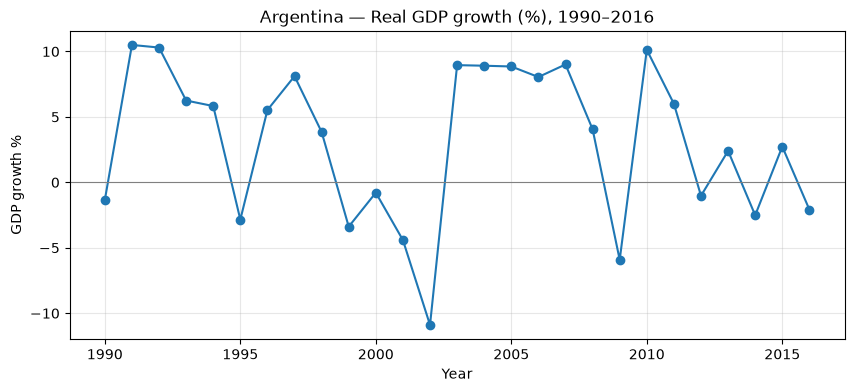

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the annual dataset we built
weo = pd.read_csv("data/interim/weo_annual_long.csv")

print("Shape:", weo.shape)
print("Countries:", weo['iso3'].nunique())
print("Variables:", weo['variable'].nunique())
print("\nVariables available:")
print(weo['variable'].unique())

# Look at one country's GDP growth over time — Argentina
arg = weo[(weo['iso3']=='ARG') & (weo['variable']=='gdp_growth_pct') & (~weo['is_forecast'])]
plt.figure(figsize=(10,4))
plt.plot(arg['year'], arg['value'], marker='o')
plt.title("Argentina — Real GDP growth (%), 1990–2016")
plt.xlabel("Year"); plt.ylabel("GDP growth %")
plt.axhline(0, color='grey', linewidth=0.8)
plt.grid(alpha=0.3)
plt.show()

In [4]:
# Load crisis years so we can mark them on the plots
crises = pd.read_csv("data/interim/lv_currency_crises_parsed.csv")
sample = pd.read_csv("data/interim/final_sample_countries.csv")

# Map LV names -> iso3 so crises align with the WEO data
name_to_iso = dict(zip(sample['lv_name'], sample['iso3']))
crises['iso3'] = crises['lv_name'].map(name_to_iso)

def plot_country(iso3, variable='gdp_growth_pct'):
    """Plot one variable for one country, with crisis years marked as red lines."""
    d = weo[(weo['iso3']==iso3) & (weo['variable']==variable) & (~weo['is_forecast'])]
    cy = crises[crises['iso3']==iso3]['crisis_year'].tolist()
    
    plt.figure(figsize=(11,4))
    plt.plot(d['year'], d['value'], marker='o', zorder=3)
    for year in cy:
        if 1990 <= year <= 2016:
            plt.axvline(year, color='red', alpha=0.6, linestyle='--', zorder=1)
    plt.title(f"{iso3} — {variable}  (red dashed = crisis year)")
    plt.xlabel("Year"); plt.ylabel(variable)
    plt.axhline(0, color='grey', linewidth=0.8)
    plt.grid(alpha=0.3)
    plt.show()

# Try a few crisis-heavy countries
plot_country('ARG', 'gdp_growth_pct')
plot_country('ARG', 'inflation_avg_pct')
plot_country('TUR', 'gdp_growth_pct')

KeyError: 'lv_name'

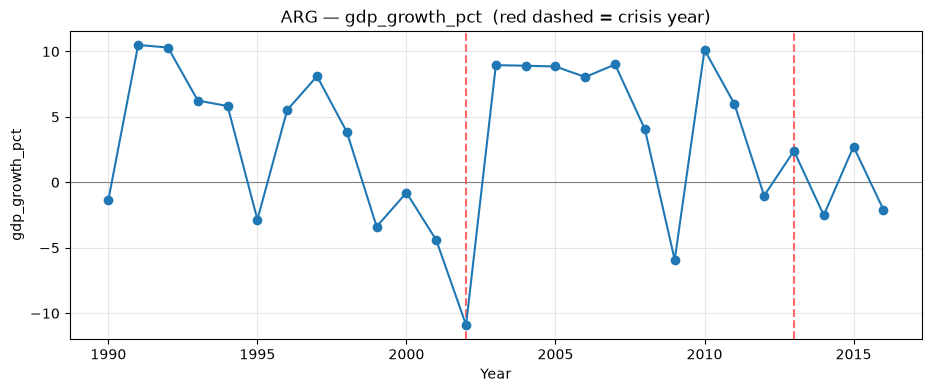

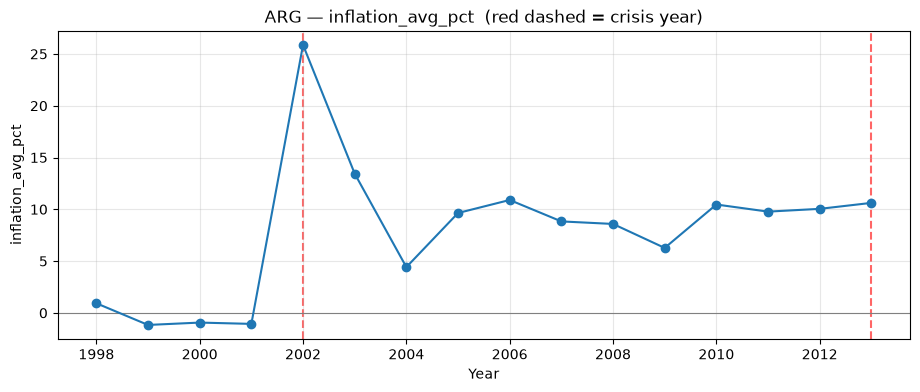

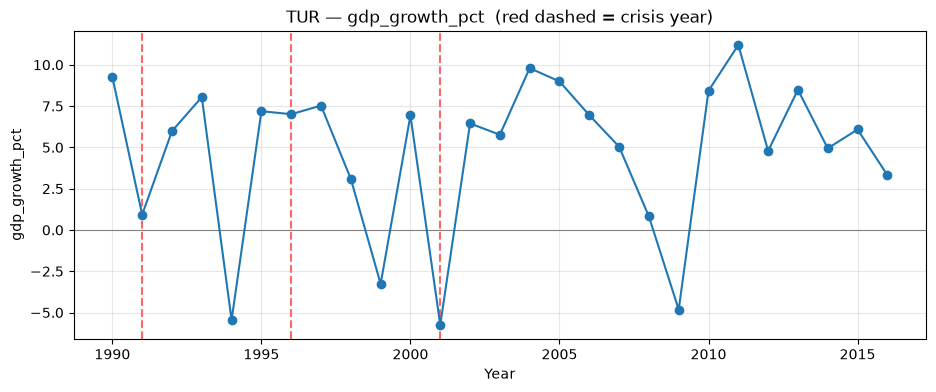

In [5]:
# Load crisis years so we can mark them on the plots
crises = pd.read_csv("data/interim/lv_currency_crises_parsed.csv")
sample = pd.read_csv("data/interim/final_sample_countries.csv")

# The crises file has 'country' (LV name); map it to iso3 via the sample file
name_to_iso = dict(zip(sample['lv_name'], sample['iso3']))
crises['iso3'] = crises['country'].map(name_to_iso)

def plot_country(iso3, variable='gdp_growth_pct'):
    """Plot one variable for one country, with crisis years marked as red lines."""
    d = weo[(weo['iso3']==iso3) & (weo['variable']==variable) & (~weo['is_forecast'])]
    cy = crises[crises['iso3']==iso3]['crisis_year'].tolist()
    
    plt.figure(figsize=(11,4))
    plt.plot(d['year'], d['value'], marker='o', zorder=3)
    for year in cy:
        if 1990 <= year <= 2016:
            plt.axvline(year, color='red', alpha=0.6, linestyle='--', zorder=1)
    plt.title(f"{iso3} — {variable}  (red dashed = crisis year)")
    plt.xlabel("Year"); plt.ylabel(variable)
    plt.axhline(0, color='grey', linewidth=0.8)
    plt.grid(alpha=0.3)
    plt.show()

# Try a few crisis-heavy countries
plot_country('ARG', 'gdp_growth_pct')
plot_country('ARG', 'inflation_avg_pct')
plot_country('TUR', 'gdp_growth_pct')

In [6]:
# Check exactly which years are marked for Argentina
print("Argentina crisis years in our file:")
print(crises[crises['iso3']=='ARG']['crisis_year'].tolist())

Argentina crisis years in our file:
[1975, 1981, 1987, 2002, 2013]
